# Setup

In [1]:
import os
from matplotlib import pyplot as plt
import skeliner as sk

In [2]:
import sys

sys.path.append("../utils")

import data_io

In [3]:
config = data_io.get_data_config()
version = config.get("version", None)
skel_dir = config.get("skel_dir", None)
file_path = data_io.get_file_path(config)

assert os.path.isdir(skel_dir), skel_dir
assert os.path.isfile(file_path), file_path

# Figure

In [4]:
from style import set_rc_params

set_rc_params()

In [5]:
fig_dir = f'../figures/examples/v{version}'
os.makedirs(fig_dir, exist_ok=True)

In [6]:
skel_files = {
    'XBC': '720575940543904349.swc',
    'sON alpha': '720575940563641563.swc',
    'ON SAC': '720575940573959984.swc',
    'WFAC': '720575940557940516.swc',
 }

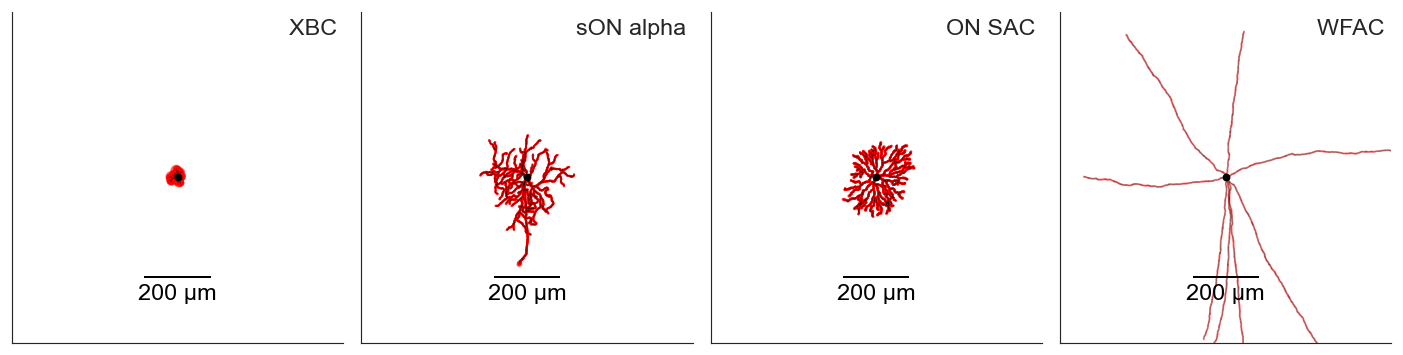

In [7]:
fig, axs = plt.subplots(1, len(skel_files), figsize=(3*len(skel_files), 3))

for i, (celltype, skel_file) in enumerate(skel_files.items()):
    skel = sk.io.load_swc(os.path.join(skel_dir, skel_file))

    sx, sy, sz = skel.soma.center

    ax = axs[i]
    ax.set_title(celltype + ' ', y=.95, va='top', loc='right', fontsize=14)
    sk.plot.projection(skel, ax=ax, plane='xy')
    ax.set_aspect('equal', 'box')

    ax.set_xlim(sx-500, sx+500)
    ax.set_ylim(sy-500, sy+500)

    size = 200
    y0 = sy-300
    ax.plot([sx-size/2, sx+size/2], [y0, y0], c='k', solid_capstyle='butt')
    ax.text(sx, y0-20, f'{size} µm', c='k', ha='center', va='top', fontsize=14)
    ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'examples.pdf'), transparent=True)
plt.savefig(os.path.join(fig_dir, 'examples.png'), dpi=600, transparent=True)
plt.show()